# Insights on Single-Family Sales in Chicago
### 10 Questions for a Chicago Real-Estate Trivia Night

A tour of who bought Chicago's single-family homes in 2022–2025, where, for how
much, and — increasingly — *what kind of buyer*. Every chart answers one trivia
question; guess before you scroll.

The sample is the **clean, arm's-length** Chicago single-family cross-section
(non-market transfers dropped up front — see Setup), so every sale here is a real
market price. Compute lives in `analysis/sales_descriptives.py`; renderers in
`viz/charts.py` (**entity = orange, individual = blue** wherever the two are split).

In [184]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from chicago_housing import constants as K
from chicago_housing.data.load import load_training_data
from chicago_housing.data import wrangling
from chicago_housing.analysis import sales_descriptives as sd
from chicago_housing.viz import charts, maps

pd.set_option('display.max_rows', 120)
pd.set_option('display.float_format', lambda v: f'{v:,.3f}')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Setup — the clean sample (non-market sales dropped first)

Scope → recode → classify → **drop non-arm's-length**. The countywide parquet
(405,195 rows) narrows to Chicago / single-family / 2022–25 / single-card
(44,015), then dropping non-market transfers leaves **40,633**. We keep the
entity/stale flag columns so we can still split entity vs individual downstream.

Finally we drop **102 sales (0.25%)** that have no community-area label
(unmappable parcels) so that every neighborhood-, region-, and citywide tally in
this notebook reconciles — leaving **40,531**.

In [ ]:
# One-call setup (wrangling.load_sales_sample): load -> scope -> classify + drop
# non-market -> attach region. Property-type config lives in K.SF; swap for
# K.MF / K.CONDO to run the identical analysis on the other markets.
enriched = wrangling.load_sales_sample(K.SF)
print("clean single-family sample:", enriched.shape)

In [186]:
# Getting community area mapping to cardinal directions
nbhood_mapping = enriched[['region','loc_chicago_community_area_name',]].drop_duplicates()
nbhood_mapping.sort_values(by='region')

,region,loc_chicago_community_area_name
822,North,EDGEWATER
1946,North,LINCOLN SQUARE
1162,North,WEST RIDGE
954,North,MONTCLARE
772,North,HERMOSA
756,North,LOGAN SQUARE
735,North,LINCOLN PARK
615,North,FOREST GLEN
613,North,BELMONT CRAGIN
610,North,AVONDALE


## First, the lay of the land — Chicago's three sides

Before the trivia, a map. Chicagoans split the city by the **arms of the Chicago
River**, a division that goes back to the city's original 1830 plat: everything
north-and-east of the river is the **North Side**, the wedge caught between the
river's branches is the **West Side**, and everything south of the main stem is
the **South Side** ([UChicago, *Sides*](https://chicagostudies.uchicago.edu/sides)).
The Loop (downtown) sits at the confluence where the three meet.

We use those three sides throughout. A few housekeeping calls, all following the
city's official community-area lists: the *Northwest Side* folds into North, the
*Southwest* and *Far South* into South, and the Central areas by geography
(Near North → North, Near South/West → their names).

> **† "East Side."** Chicago has a community area literally named *East Side* — but
> it's named for the **Calumet** River, not the Chicago, and the city files it
> under the South Side (Far Southeast). It's a neighborhood, not a fourth cardinal
> "side," so we count it in the South.

Single-family sales are lopsided across the three: the **South (54%)** and
**North (37%)** dominate, while the **West Side is just 9%** — most of its housing
is multifamily, not single-family.

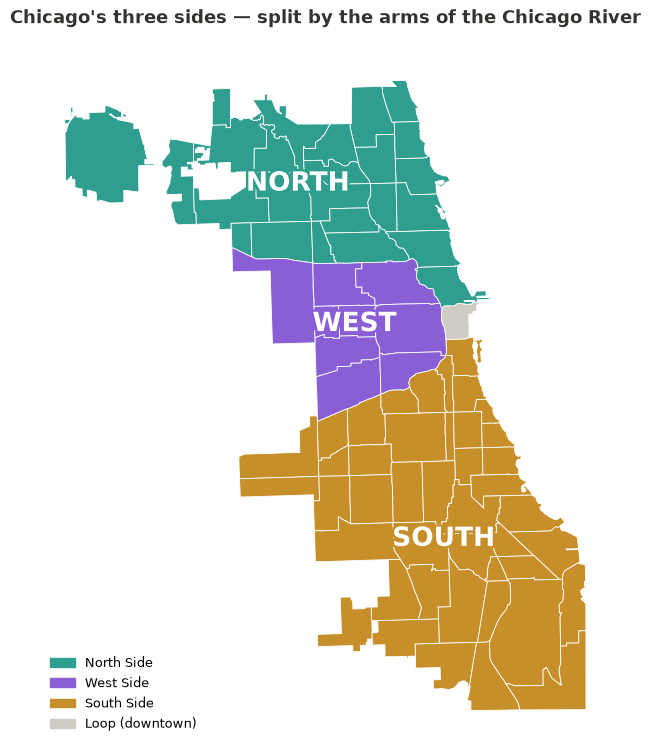

In [187]:
# Static side-map (the Substack PNG). Community areas coloured N/W/S; Loop greyed.
maps.region_map_static()
plt.show()

# Interactive companion — hover any area for its name, side, and SF sale count.
maps.region_map(enriched).save("region_map.html")

---
## Q1 — How many single-family homes sold in Chicago in 2025?

**≈ 9,600 — down a fifth from 2022, but the drop was a single cliff.** Sales fell
**20%** in 2023 (mortgage rates roughly doubled) and have flat-lined since:
−1% in 2024, +1% in 2025. The market didn't keep sinking — it stepped down once
and stayed there.

The per-neighborhood table below shows where the drop bit hardest: the
bungalow-belt on the Northwest/Southwest edges (Norwood Park, Portage Park,
Dunning, Garfield Ridge) shed a quarter to a third of their volume, while several
South Side areas (Auburn Gresham, West Pullman) barely moved.

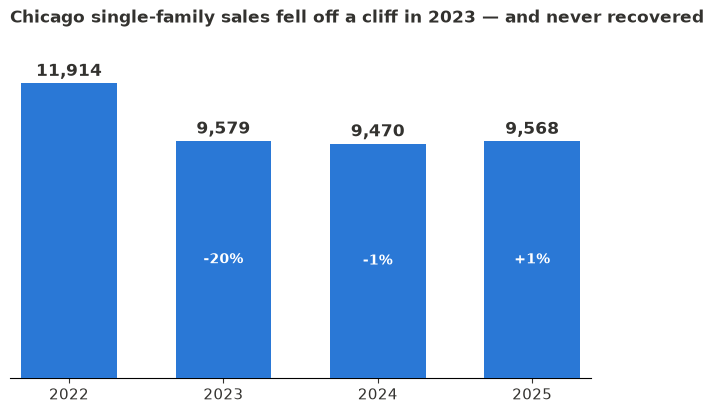

In [188]:
charts.plot_total_sales_by_year(
    sd.sales_by_year(enriched),
    title="Chicago single-family sales fell off a cliff in 2023 — and never recovered")
plt.show()

In [189]:
# Per-neighborhood sale volume 2022->2025 (busiest first) — the data behind Q2.
nb_vol = sd.sales_by_neighborhood_wide(enriched,group_by='region')
_tot = nb_vol[['2022', '2023', '2024', '2025']].sum()
print(f"CITYWIDE  2022={_tot['2022']:,}  2023={_tot['2023']:,}  "
      f"2024={_tot['2024']:,}  2025={_tot['2025']:,}   ({len(nb_vol)} regions)")
nb_vol

CITYWIDE  2022=11,914  2023=9,579  2024=9,470  2025=9,568   (3 regions)


meta_year,region,2022,2023,2024,2025,delta_pct
0,South,6254,5264,5072,5223,-16.500
1,North,4583,3445,3520,3416,-25.500
2,West,1077,870,878,929,-13.700


In [190]:
# Per-neighborhood sale volume 2022->2025 (busiest first) — the data behind Q2.
nb_vol = sd.sales_by_neighborhood_wide(enriched)
_tot = nb_vol[['2022', '2023', '2024', '2025']].sum()
print(f"CITYWIDE  2022={_tot['2022']:,}  2023={_tot['2023']:,}  "
      f"2024={_tot['2024']:,}  2025={_tot['2025']:,}   ({len(nb_vol)} neighborhoods)")
nb_vol

CITYWIDE  2022=11,914  2023=9,579  2024=9,470  2025=9,568   (76 neighborhoods)


meta_year,loc_chicago_community_area_name,region,2022,2023,2024,2025,delta_pct
0,ROSELAND,South,481,394,372,420,-12.700
1,AUBURN GRESHAM,South,343,287,281,336,-2.000
2,NORWOOD PARK,North,451,346,336,323,-28.400
3,PORTAGE PARK,North,426,370,360,316,-25.800
4,DUNNING,North,429,328,328,315,-26.600
5,WEST PULLMAN,South,314,277,276,305,-2.900
6,AUSTIN,West,350,303,314,302,-13.700
7,ASHBURN,South,368,317,318,286,-22.300
8,GARFIELD RIDGE,South,374,307,270,256,-31.600
9,WASHINGTON HEIGHTS,South,300,273,235,255,-15.000


---
## Q3 — As sales fell, did prices fall too? And where are Chicago's priciest blocks?

**No — prices rose.** Even as volume dropped a fifth, the **citywide median gained
+7.4%** ($309k → $332k from 2022 to 2025), and nearly every neighborhood went up.
Fewer homes changed hands, but the ones that did sold for more.

And two maps of the city barely overlap:

- **The cheapest neighborhoods are the busiest.** The ten highest-volume areas are
  affordable South- and Northwest-side blocks — Roseland ($161k), West Pullman
  ($159k), Auburn Gresham ($200k).
- **The priciest are a North-side lakefront club.** The ten most-expensive are
  *entirely* North/West: **North Center tops the city at a $1.62M median** (+42%!),
  with Lincoln Park ($1.60M) and Lake View ($1.59M) right behind. **Not one South
  Side neighborhood cracks the top ten.**

Below: the full 76-neighborhood price table (2022 → 2025), then the two ends —
busiest and priciest — as before/after bars. *(Medians off very few sales swing
wildly — e.g. Riverdale, n=14 — so the "most expensive" ranking requires ≥10 sales
in 2025.)*

In [191]:
# Full 76-neighborhood median price, 2022 vs 2025 (+ counts + % change), priciest first.
price = sd.median_price_two_year(enriched, '2022', '2025').join(
    enriched[[K.REPORT_GEO, K.REGION_COL]].drop_duplicates().set_index(K.REPORT_GEO))
_cw = enriched.groupby(enriched['meta_year'].astype('string'))[K.TARGET_RAW].median()
print(f"CITYWIDE median  2022 ${_cw['2022']:,.0f}  ->  2025 ${_cw['2025']:,.0f}"
      f"  ({(_cw['2025']/_cw['2022'] - 1) * 100:+.1f}%)")
price.sort_values('med_2025', ascending=False)

CITYWIDE median  2022 $309,000  ->  2025 $332,000  (+7.4%)


,med_2022,n_2022,med_2025,n_2025,delta_pct,region
loc_chicago_community_area_name,,,,,,
NORTH CENTER,"1,145,000.000",220,"1,622,500.000",166,41.700,North
LINCOLN PARK,"1,400,000.000",300,"1,605,000.000",231,14.600,North
LAKE VIEW,"1,250,000.000",212,"1,592,500.000",154,27.400,North
NEAR NORTH SIDE,"977,500.000",82,"1,327,500.000",82,35.800,North
WEST TOWN,"964,500.000",314,"1,087,500.000",219,12.800,West
UPTOWN,"880,000.000",47,"1,050,000.000",37,19.300,North
LOGAN SQUARE,"819,000.000",261,"952,375.000",228,16.300,North
LINCOLN SQUARE,"761,750.000",128,"925,000.000",87,21.400,North
EDGEWATER,"775,000.000",82,"900,000.000",55,16.100,North


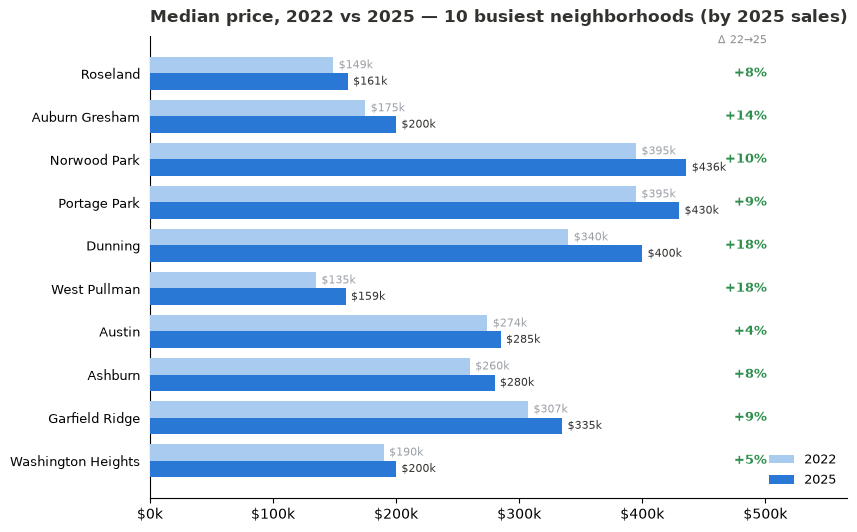

In [192]:
# Bonus 1 — the 10 busiest neighborhoods (by 2025 volume): median price then vs now.
top10_vol = sd.top_neighborhoods(
    enriched[enriched['meta_year'].astype('string') == '2025'], 10)[K.REPORT_GEO].tolist()
charts.plot_median_price_2yr(
    price, top10_vol,
    "Median price, 2022 vs 2025 — 10 busiest neighborhoods (by 2025 sales)")
plt.show()

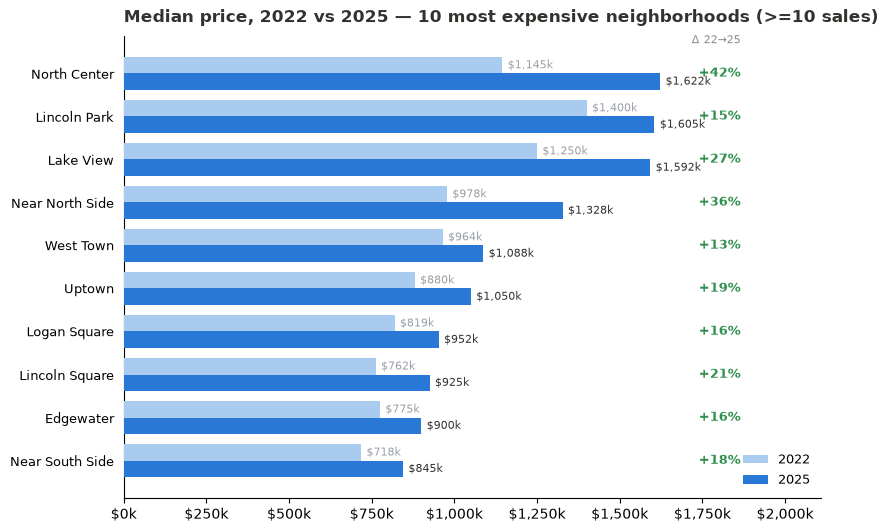

In [193]:
# Bonus 2 — the 10 most expensive neighborhoods (2025 median, >=10 sales): then vs now.
top10_exp = sd.neighborhoods_by_year_price(
    enriched, year='2025', min_sales=10).head(10).index.tolist()
charts.plot_median_price_2yr(
    price, top10_exp,
    "Median price, 2022 vs 2025 — 10 most expensive neighborhoods (>=10 sales)")
plt.show()

---
## Q4 — What's the most expensive single-family home sold in Chicago?

**An $8.0 million Gold Coast mansion** — 6,767 sqft, built 2006, 5 bed / 5 bath in
**Near North Side**, sold in 2022 at **$1,182 a square foot**. The whole trophy
tier is a two-neighborhood club: **every one of the ten priciest sales across both
years sits in Near North Side or Lincoln Park**, all North Side.

Two twists worth a trivia beat:
- **The top cooled while the middle rose.** 2025's most expensive home ($7.17M) came
  in *below* 2022's $8.0M — even though the citywide median climbed +7% (Q3). The
  luxury peak softened as the broad market firmed.
- **Price per foot ≠ price.** The steepest $/sqft isn't the priciest house: a $5.7M
  Lincoln Park home went for **$1,362/sqft** in 2022, out-pricing the $8M sale per
  square foot — it's just smaller.

Below: the top 5 of 2022, the top 5 of 2025, then a combined leaderboard.

In [194]:
# Top 5 most expensive single-family sales — 2022, then 2025 (single-year views).
from IPython.display import display
display(sd.top_sales(enriched, '2022', 5).style.hide(axis='index')
        .format({'price': '${:,.0f}', '$/sqft': '${:,.0f}'}).set_caption('Top 5 — 2022'))
display(sd.top_sales(enriched, '2025', 5).style.hide(axis='index')
        .format({'price': '${:,.0f}', '$/sqft': '${:,.0f}'}).set_caption('Top 5 — 2025'))

year,price,$/sqft,sqft,beds,baths,year_built,neighborhood,address,side
2022,"$8,000,000","$1,182",6767,5,5,2006,Near North Side,15 W BURTON PL,North
2022,"$6,200,000","$1,121",5530,5,4,2006,Lincoln Park,1841 N ORCHARD ST,North
2022,"$5,800,000",$908,6387,5,6,2008,Lincoln Park,1849 N BURLING ST,North
2022,"$5,700,000","$1,362",4184,4,4,1999,Lincoln Park,1935 N BURLING ST HSE,North
2022,"$5,650,000",$991,5699,4,4,1994,Lincoln Park,1837 N ORCHARD ST,North


year,price,$/sqft,sqft,beds,baths,year_built,neighborhood,address,side
2025,"$7,165,000",$838,8549,6,8,2011,Near North Side,445 W SUPERIOR ST,North
2025,"$6,750,000",$875,7711,6,5,1905,Near North Side,1515 N STATE ST,North
2025,"$6,750,000","$1,159",5826,6,4,2008,Lincoln Park,741 W ARMITAGE AVE,North
2025,"$6,650,000",$822,8088,7,6,1912,Near North Side,1521 N STATE PKWY,North
2025,"$5,400,000",$976,5530,6,6,2006,Lincoln Park,1841 N ORCHARD ST,North


In [195]:
# Combined leaderboard — both years' top 5, ranked by price (the trophy tier at a glance).
combined = (pd.concat([sd.top_sales(enriched, '2022', 5), sd.top_sales(enriched, '2025', 5)])
              .sort_values('price', ascending=False).reset_index(drop=True))
combined.style.hide(axis='index').format({'price': '${:,.0f}', '$/sqft': '${:,.0f}'}) \
    .set_caption('Most expensive SF sales, 2022 & 2025 combined')

year,price,$/sqft,sqft,beds,baths,year_built,neighborhood,address,side
2022,"$8,000,000","$1,182",6767,5,5,2006,Near North Side,15 W BURTON PL,North
2025,"$7,165,000",$838,8549,6,8,2011,Near North Side,445 W SUPERIOR ST,North
2025,"$6,750,000",$875,7711,6,5,1905,Near North Side,1515 N STATE ST,North
2025,"$6,750,000","$1,159",5826,6,4,2008,Lincoln Park,741 W ARMITAGE AVE,North
2025,"$6,650,000",$822,8088,7,6,1912,Near North Side,1521 N STATE PKWY,North
2022,"$6,200,000","$1,121",5530,5,4,2006,Lincoln Park,1841 N ORCHARD ST,North
2022,"$5,800,000",$908,6387,5,6,2008,Lincoln Park,1849 N BURLING ST,North
2022,"$5,700,000","$1,362",4184,4,4,1999,Lincoln Park,1935 N BURLING ST HSE,North
2022,"$5,650,000",$991,5699,4,4,1994,Lincoln Park,1837 N ORCHARD ST,North
2025,"$5,400,000",$976,5530,6,6,2006,Lincoln Park,1841 N ORCHARD ST,North


---
## Q5 — Do investors pay less than the rest of us?

**Only if you say where.** Citywide it looks like a landslide, but the "discount"
is a *map*, not a behavior:

- **South & West sides:** entity buyers pay **~55% less** — and **~55% less *per
  square foot* too**, so it isn't merely that they buy smaller homes.
- **North Side:** the gap **vanishes** — entities pay the same per foot as everyone
  else ($385 vs $385 in 2025).
- **Prime North (Lincoln Park):** entities pay a **+28% *premium* per foot** — a
  different animal entirely (luxury developers / teardown-rebuild buyers), which
  Q6 names.

So "do investors pay less?" honestly answers to: **on the South and West sides, yes
— a lot; on the North Side, no.** A single citywide number would be a mirage.

> **Caveat — it's an association, not a proven discount.** $/sqft still doesn't
> control for **condition**. Investors buy distressed / rehab-ready homes, which
> genuinely sell for less per foot. So read this as *where investors concentrate
> and what they pay* — not "the same house, cheaper."

,group,year,n_ent,n_ind,ent_share,price_ent,price_ind,ppsf_ent,ppsf_ind,price_diff_pct,ppsf_diff_pct,reliable
0,North,2022,418,4165,9.000,"532,875.000","479,000.000",350.000,337.000,11.000,4.000,True
1,West,2022,139,938,13.000,"192,000.000","368,250.000",156.000,274.000,-48.000,-43.000,True
2,South,2022,1209,5045,19.000,"105,000.000","245,000.000",94.000,208.000,-57.000,-55.000,True
3,North,2025,494,2922,14.000,"555,000.000","560,000.000",385.000,385.000,-1.000,0.000,True
4,West,2025,157,772,17.000,"175,000.000","394,998.000",148.000,307.000,-56.000,-52.000,True
5,South,2025,1113,4110,21.000,"115,000.000","270,844.000",102.000,232.000,-58.000,-56.000,True


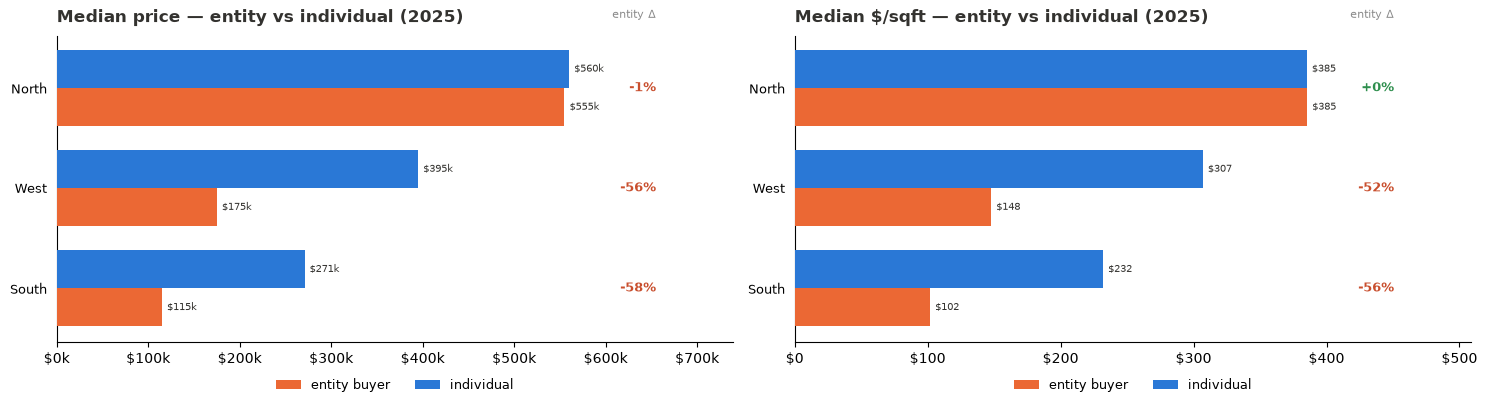

In [196]:
# Entity-buyer vs individual — median price AND $/sqft, by side (2022 & 2025).
from IPython.display import display
side = sd.entity_individual_split(enriched, K.REGION_COL, years=('2022', '2025'))
display(side.round(0))

side25 = side[side['year'] == '2025']
fig, axes = plt.subplots(1, 2, figsize=(15, 4.2))
charts.plot_entity_metric_by_group(side25, K.REGION_ORDER, 'price',
    "Median price — entity vs individual (2025)", money='k', ax=axes[0])
charts.plot_entity_metric_by_group(side25, K.REGION_ORDER, 'ppsf',
    "Median $/sqft — entity vs individual (2025)", money='plain', ax=axes[1])
fig.tight_layout(); plt.show()

,group,year,n_ent,n_ind,ent_share,price_ent,price_ind,ppsf_ent,ppsf_ind,price_diff_pct,ppsf_diff_pct,reliable
0,ASHBURN,2025,49,237,17.000,"199,900.000","295,000.000",194.000,260.000,-32.000,-25.000,True
1,AUBURN GRESHAM,2025,92,244,27.000,"115,388.000","235,000.000",102.000,181.000,-51.000,-44.000,True
2,AUSTIN,2025,63,239,21.000,"140,000.000","325,000.000",117.000,231.000,-57.000,-49.000,True
3,DUNNING,2025,44,271,14.000,"285,325.000","410,000.000",287.000,328.000,-30.000,-12.000,True
4,GARFIELD RIDGE,2025,24,232,9.000,"251,000.000","340,000.000",209.000,314.000,-26.000,-34.000,True
5,NORWOOD PARK,2025,37,286,12.000,"385,000.000","440,000.000",324.000,344.000,-12.000,-6.000,True
6,PORTAGE PARK,2025,38,278,12.000,"345,000.000","449,000.000",247.000,327.000,-23.000,-25.000,True
7,ROSELAND,2025,137,283,33.000,"91,500.000","219,900.000",82.000,184.000,-58.000,-56.000,True
8,WASHINGTON HEIGHTS,2025,65,190,26.000,"105,000.000","245,000.000",99.000,207.000,-57.000,-52.000,True
9,WEST PULLMAN,2025,104,201,34.000,"98,500.000","210,000.000",89.000,195.000,-53.000,-54.000,True


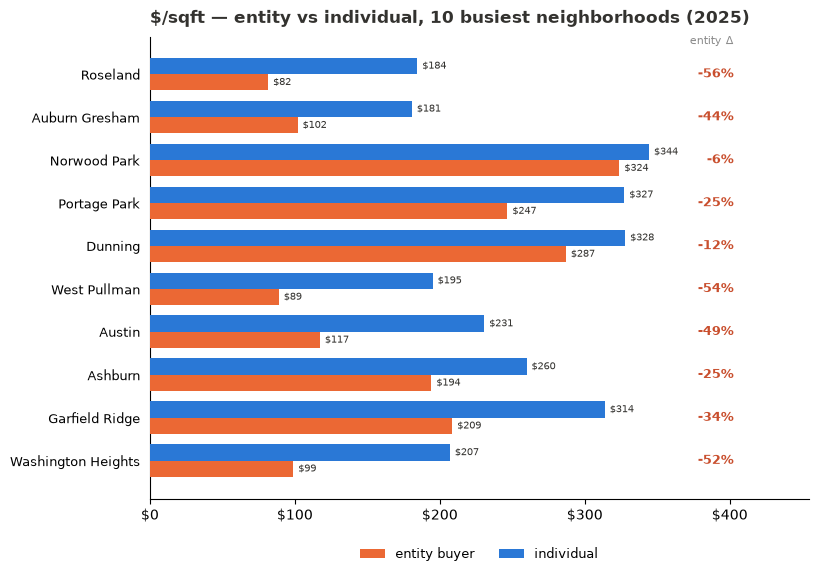

In [197]:
# 10 busiest neighborhoods (2025): entity vs individual — price + $/sqft.
vol10 = sd.top_neighborhoods(
    enriched[enriched['meta_year'].astype('string') == '2025'], 10)[K.REPORT_GEO].tolist()
vol_split = sd.entity_individual_split(
    enriched[enriched[K.REPORT_GEO].isin(vol10)], K.REPORT_GEO, years=('2025',))
display(vol_split.round(0))
charts.plot_entity_metric_by_group(
    vol_split, vol10, 'ppsf',
    "$/sqft — entity vs individual, 10 busiest neighborhoods (2025)", money='plain')
plt.show()

,group,year,n_ent,n_ind,ent_share,price_ent,price_ind,ppsf_ent,ppsf_ind,price_diff_pct,ppsf_diff_pct,reliable
0,EDGEWATER,2025,6,49,11.000,"682,500.000","920,000.000",506.000,497.000,-26.000,2.000,False
1,LAKE VIEW,2025,35,119,23.000,"1,625,000.000","1,585,000.000",629.000,642.000,2.000,-2.000,True
2,LINCOLN PARK,2025,72,159,31.000,"2,350,000.000","1,495,000.000",773.000,603.000,57.000,28.000,True
3,LINCOLN SQUARE,2025,20,67,23.000,"665,000.000","1,100,000.000",478.000,568.000,-40.000,-16.000,True
4,LOGAN SQUARE,2025,30,198,13.000,"677,500.000","981,250.000",528.000,529.000,-31.000,-0.000,True
5,NEAR NORTH SIDE,2025,17,65,21.000,"1,740,000.000","1,315,000.000",544.000,506.000,32.000,8.000,True
6,NEAR SOUTH SIDE,2025,2,40,5.000,"885,000.000","844,950.000",360.000,392.000,5.000,-8.000,False
7,NORTH CENTER,2025,29,137,18.000,"950,000.000","1,670,000.000",629.000,642.000,-43.000,-2.000,True
8,UPTOWN,2025,4,33,11.000,"850,000.000","1,100,102.000",541.000,513.000,-23.000,5.000,False
9,WEST TOWN,2025,29,190,13.000,"775,000.000","1,132,500.000",498.000,542.000,-32.000,-8.000,True


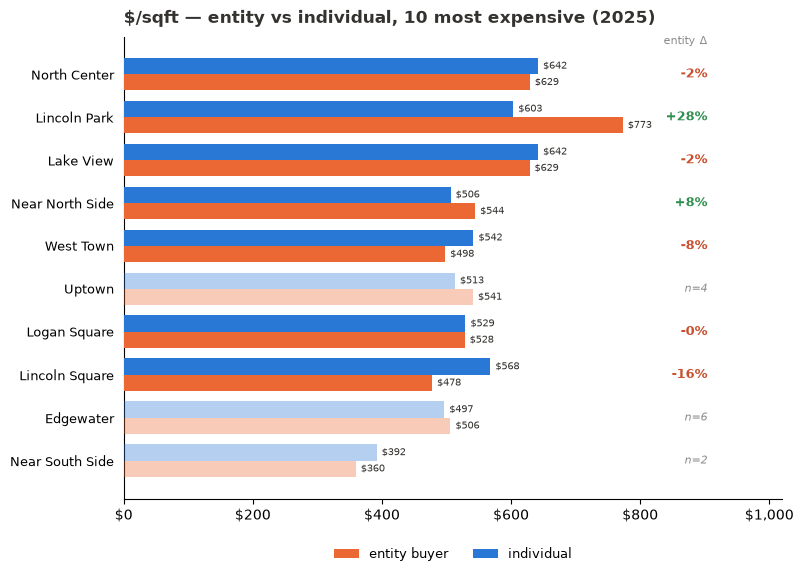

In [198]:
# 10 most expensive neighborhoods (2025 median, >=10 sales): entity vs individual.
# Faded bars / n= flags = fewer than 10 entity buys (gap suppressed as unreliable).
exp10 = sd.neighborhoods_by_year_price(
    enriched, year='2025', min_sales=10).head(10).index.tolist()
exp_split = sd.entity_individual_split(
    enriched[enriched[K.REPORT_GEO].isin(exp10)], K.REPORT_GEO, years=('2025',))
display(exp_split.round(0))
charts.plot_entity_metric_by_group(
    exp_split, exp10, 'ppsf',
    "$/sqft — entity vs individual, 10 most expensive (2025)", money='plain')
plt.show()

---
## Q6 — So who *are* these investors, and where do they play?

**Meet Grandview** — Chicago's most active single-family buyer, **164 homes in four
years** (~$27M) at a **$147k median**: cheap South-side stock spread across Ashburn,
Austin, Roseland and Morgan Park. Behind it the leaderboard is a **wall of South-side
value investors** — Bricksave (89 homes, $75k median, home turf Roseland), Commercial
Acquisitions (50, Ashburn), Illinois Land Investment (34 homes at a **$35k** median —
teardown territory in Englewood).

**One name doesn't belong — and that's the tell.** *Chicago Title Land Trust* appears
with 25 Lincoln Park buys at a **$460k median and $53M total** — an order of magnitude
pricier than the rest. It isn't an investor; it's a **privacy vehicle** wealthy
North-side buyers use to keep their names off the deed. That's the Q5 premium in the
flesh: on the North Side, "entity" often just means a rich person in a trust.

**But nobody owns the block.** Across 2022–25 there were **4,345 distinct entity
buyers**, and **3,602 bought exactly one home**. Even Grandview, the giant, is 164 of
6,665 entity buys — under 3%. Chicago's investor market isn't a monopoly; it's a long
tail of small players, with a handful of South-side rehabbers at the front.

Below: the leaderboard (coloured by each firm's home-turf side), then a "who buys
where" heatmap of their turf.

In [199]:
# Entity-buyer leaderboard (2022-25 pooled) + the long-tail concentration check.
from IPython.display import display
_names = sd.normalize_entity_name(enriched.loc[enriched['entity_buyer'], K.BUYER_NAME])
print(f"entity buys: {int(enriched['entity_buyer'].sum()):,}   distinct buyers: "
      f"{_names.nunique():,}   bought exactly once: {int((_names.value_counts() == 1).sum()):,}")

lb = sd.entity_buyer_leaderboard(enriched, n=15)
display(lb.style.hide(axis='index')
        .format({'median_price': '${:,.0f}', 'total_spent': '${:,.0f}'}))

entity buys: 6,665   distinct buyers: 4,246   bought exactly once: 3,479


entity,homes,median_price,total_spent,top_side,home_turf
GRANDVIEW,164,"$146,500","$27,168,150",South,ASHBURN (13/164)
BRICKSAVE,95,"$75,000","$6,841,150",South,ROSELAND (20/95)
COMMERCIAL ACQUISITIONS,51,"$265,000","$13,503,597",South,ASHBURN (15/51)
COMMUNITY INITIATIVES,45,"$88,433","$4,010,034",South,AUBURN GRESHAM (7/45)
ILLINOIS LAND INVESTMENT,34,"$35,000","$1,301,000",South,ENGLEWOOD (7/34)
TENTAZIONE,33,"$108,000","$3,556,199",South,SOUTH DEERING (13/33)
CISCO HOUSING SOLUTIONS,27,"$90,000","$2,625,500",South,ROSELAND (7/27)
CONNOLLY CAPITAL,26,"$155,509","$3,896,272",South,ASHBURN (9/26)
TULE RIVER HOMEBUYER EARNED EQUITY AGENCY,25,"$295,000","$7,595,135",South,ASHBURN (5/25)
SECOND CITY EQUITY,25,"$105,000","$2,951,200",South,AUBURN GRESHAM (3/25)


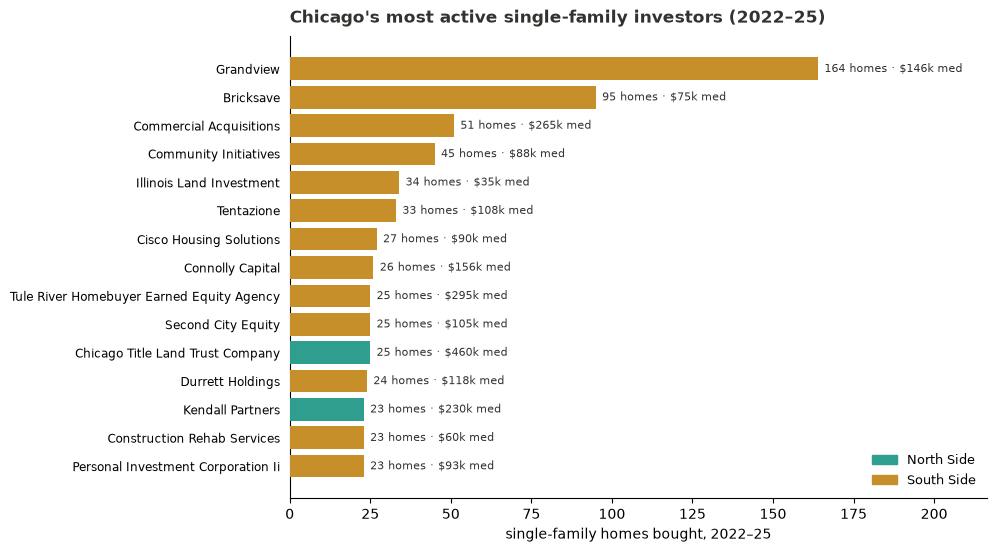

In [200]:
# Leaderboard chart — bars coloured by each firm's home-turf side (South = gold).
charts.plot_entity_buyer_leaderboard(
    lb, n=15, title="Chicago's most active single-family investors (2022–25)")
plt.show()

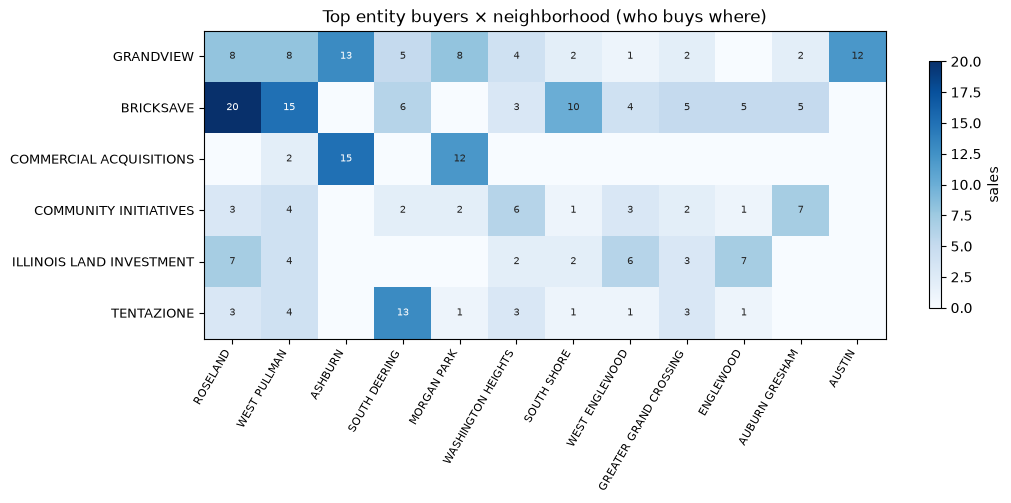

In [201]:
# Where they play — top-6 entity buyers × their most-active neighborhoods.
mat = sd.entity_neighborhood_matrix(enriched, side='buyer',
                                    top_entities_n=6, top_neighborhoods_n=12)
charts.plot_entity_neighborhood_heatmap(mat)
plt.show()

---
## Q7 — How many Chicago homes get flipped, and where?

**At least 2,442** — single-family parcels bought and resold *within a year* over
2022–25. (A floor, not a census: a four-year window only catches flips whose buy
**and** sell both land inside it.) And flipping is a **South Side trade** — 7.9% of
all South Side sales were flips, versus just 3.4% on the North Side.

Zoom to neighborhoods and it's stark: **1 in 7 home sales in Calumet Heights, and 1
in 8 in Roseland, was a flip** (Roseland alone: 202). Almost every top-flip
neighborhood is South Side.

And it's an *investor* trade — **73% of these flips were bought by an LLC or other
entity**, the same firms from Q6 (Grandview and the South-side value buyers). The
flip is where the investor story pays off. *How much* it pays is Q8.

In [202]:
# Flips: the SAME parcel bought & resold within a year (both legs arm's-length).
flip_pairs = sd.flips(enriched, max_hold_days=365)
print(f"flips (resold within 365 days): {len(flip_pairs):,}   "
      f"bought by an entity/LLC: {flip_pairs['entity_buyer'].mean()*100:.0f}%")
# flip SHARE of all sales, by region (the South-Side skew)
sd.flip_geography(enriched, flip_pairs, by=K.REGION_COL, min_sales=0)

flips (resold within 365 days): 2,442   bought by an entity/LLC: 73%


,region,total,flips,med_return,flip_share
0,South,21813,1715,1.075,7.900
1,West,3754,212,0.765,5.600
2,North,14964,515,0.562,3.400


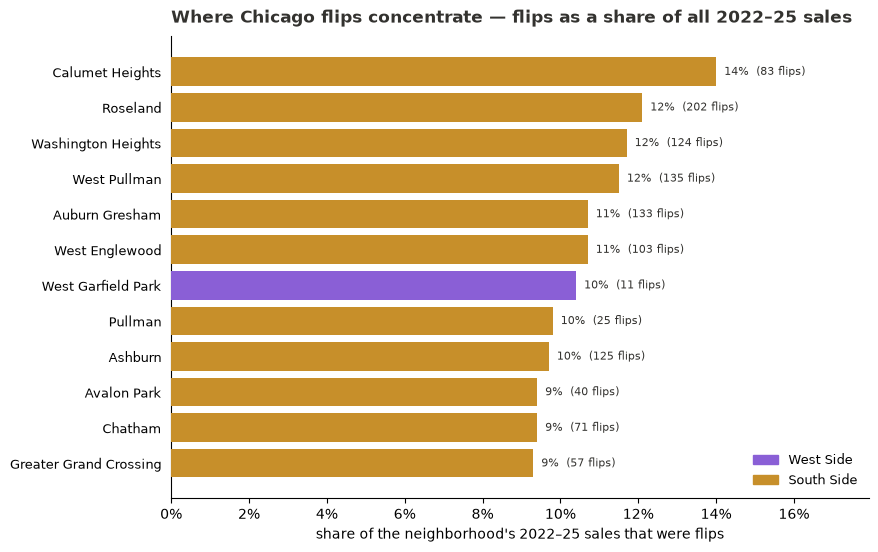

In [203]:
# Flip SHARE by neighborhood (>=100 sales) — the "1 in N sales was a flip" chart.
flip_geo = sd.flip_geography(enriched, flip_pairs, min_sales=100, n=12)
charts.plot_flip_share(
    flip_geo, n=15,
    title="Where Chicago flips concentrate — flips as a share of all 2022–25 sales")
plt.show()

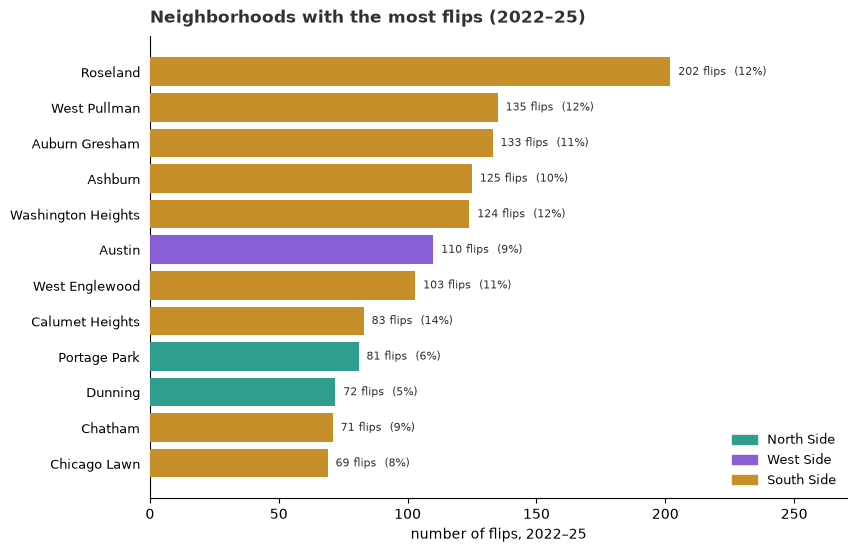

In [204]:
# Companion view — neighborhoods with the most flips by COUNT (Roseland leads on
# volume; the North/West high-volume markets Austin, Portage Park, Dunning appear here).
flip_count = sd.flip_geography(enriched, flip_pairs, min_sales=0, n=12, sort_by='flips')
charts.plot_flip_share(
    flip_count, n=12, value='flips',
    title="Neighborhoods with the most flips (2022–25)")
plt.show()

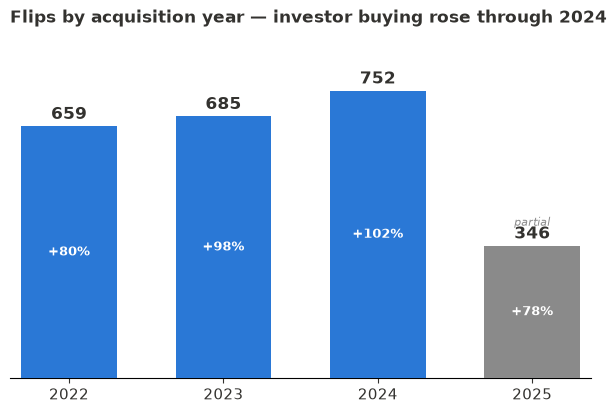

In [205]:
# Flips by acquisition (buy) year — median resale uplift labelled inside each bar.
# 2025 is greyed 'partial': a home bought in 2025 may not resell until after the data
# window ends, so its flips are still being counted.
fy = sd.flips_by_year(flip_pairs, by='buy')
charts.plot_flips_by_year(
    fy, partial_years=(2025,),
    title="Flips by acquisition year — investor buying rose through 2024")
plt.show()

---
## Q8 — How fast is a flip, and how much does it pay?

**The typical flip bought a house for ~$135k and resold it for ~$285k just six months
later — a +92% jump.** Half of all flips turned around in **under 194 days**; over
1,000 did it in under six months.

And the *cheaper* the block, the bigger the multiple: **Pullman flips resold for a
median +172%**, West Englewood +162%, Roseland +148% — buy around $80k, resell around
$240k. The most extreme we found: **10720 S Church St, Morgan Park — bought for
$40,000, resold for $530,000** (+1,225%) inside a year.

> **The honesty line: this is gross resale uplift, not profit.** These are distressed
> homes bought cheap and gut-renovated; the figure doesn't subtract the rehab,
> carrying, or transaction costs that eat most of it. Read it as *how far the price
> moved* — the value a flipper adds and captures — not money for nothing.

In [206]:
# The headline: median buy -> resale, and how fast (flip_pairs from Q7).
print(f"median flip:  buy ${flip_pairs['buy_price'].median():,.0f}  ->  resale "
      f"${flip_pairs['sell_price'].median():,.0f}   "
      f"(+{flip_pairs['gross_return'].median()*100:.0f}%, "
      f"{flip_pairs['hold_days'].median():.0f} days)")
for d in (90, 180, 270, 365):
    print(f"  flipped within {d:>3} days: {int((flip_pairs['hold_days'] <= d).sum()):,}")

median flip:  buy $134,500  ->  resale $285,000   (+92%, 193 days)
  flipped within  90 days: 436
  flipped within 180 days: 1,096
  flipped within 270 days: 1,860
  flipped within 365 days: 2,442


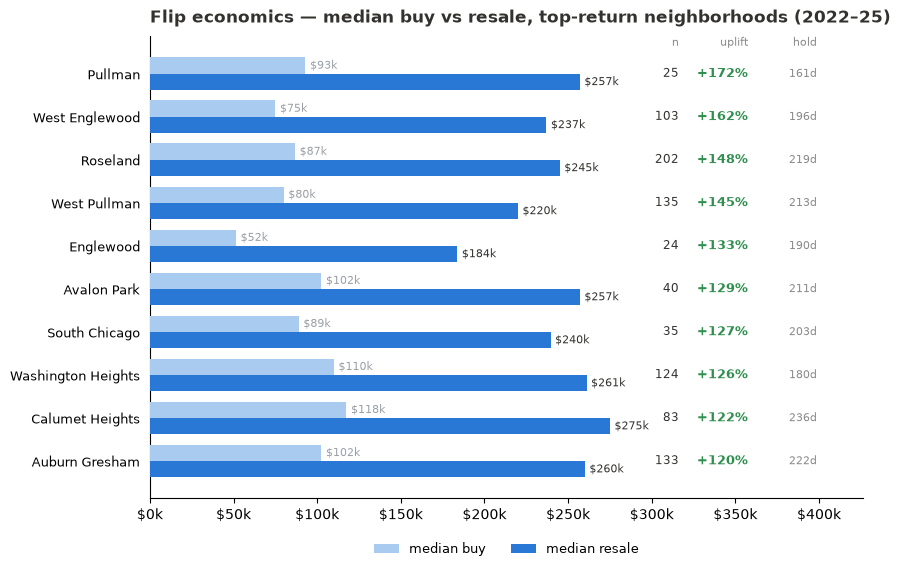

In [207]:
# Buy -> resale by neighborhood (>=20 flips), highest median uplift first.
fr = sd.flip_returns_by_neighborhood(flip_pairs, enriched, min_flips=20, n=10)
charts.plot_flip_buysell(
    fr, n=10,
    title="Flip economics — median buy vs resale, top-return neighborhoods (2022–25)")
plt.show()

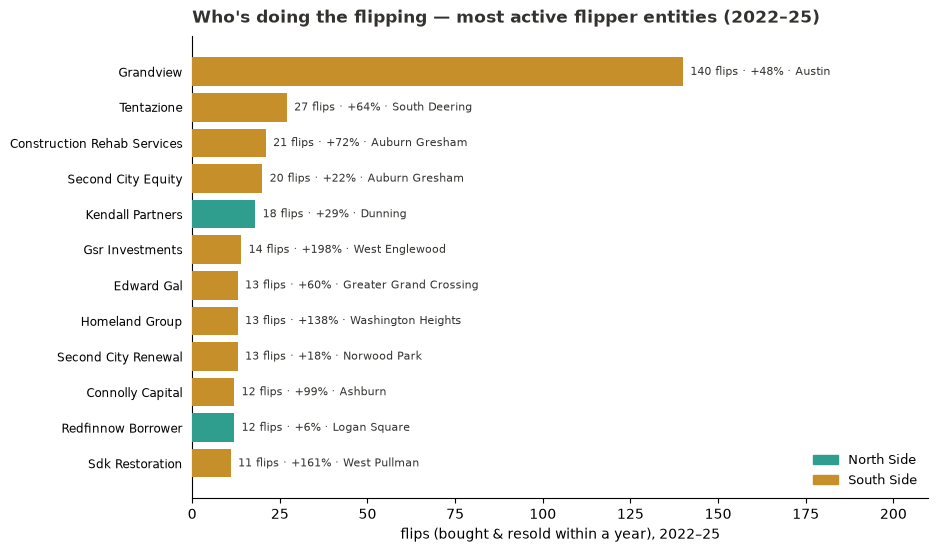

In [208]:
# Who's doing the flipping — most active flipper entities (the buy-leg buyer),
# coloured by home turf. Grandview (Q6's #1 buyer) is also the #1 flipper; the
# big-return names (GSR, Homeland, SDK) are South-side rehab specialists holding
# for months, while a few (Construction Rehab, Second City) turn around in days.
top_flip = sd.top_flippers(flip_pairs, n=12)
charts.plot_flipper_leaderboard(
    top_flip, n=12,
    title="Who's doing the flipping — most active flipper entities (2022–25)")
plt.show()

In [209]:
# The jaw-droppers — biggest flips (held >=90 days, bought >=$25k to exclude near-junk).
# bought_by / sold_by name the flipper on entry & exit; sold_to = who they resold to,
# tagged (entity = another investor) or (retail = an individual / homeowner).
from IPython.display import display
big = (flip_pairs[(flip_pairs['hold_days'] >= 90) & (flip_pairs['buy_price'] >= 25000)]
       .nlargest(10, 'gross_return')
       .assign(**{'return_%': lambda d: (d['gross_return'] * 100).round(0).astype(int),
                  'bought_by': lambda d: sd.normalize_entity_name(d['buyer_name']),
                  'sold_by': lambda d: sd.normalize_entity_name(d['seller_name']),
                  'sold_to': lambda d: sd.normalize_entity_name(d['sold_to_name']).fillna('?')
                             + d['sold_to_entity'].map({True: ' (entity)', False: ' (retail)'}).fillna('')}))
display(big[['address', K.REPORT_GEO, 'buy_price', 'sell_price', 'hold_days',
             'return_%', 'bought_by', 'sold_by', 'sold_to']]
        .style.hide(axis='index').format({'buy_price': '${:,.0f}', 'sell_price': '${:,.0f}'}))

address,loc_chicago_community_area_name,buy_price,sell_price,hold_days,return_%,bought_by,sold_by,sold_to
10720 S CHURCH ST,MORGAN PARK,"$40,000","$530,000",350,1225,JEM DEVELOPER,JEM DEVELOPERS,LOUIS C DAVIS (retail)
8218 S SAWYER AVE,ASHBURN,"$25,000","$325,000",183,1200,J PALUCH,J PALUCH CONSTRUCTION,TOMASZ PLONKA (retail)
6932 S THROOP ST,WEST ENGLEWOOD,"$25,000","$240,000",231,860,JUAN MANUEL CERVANTES GONZALEZ,JUAN MANUEL CERVANTES GONZALEZ,YARIELA A VAZQUEZ VILLA (retail)
7127 S OAKLEY AVE,CHICAGO LAWN,"$27,000","$245,000",307,807,SEEM GROUP,SEEM GROUP,IRVING J ROMAN (retail)
5917 S HONORE ST,WEST ENGLEWOOD,"$30,000","$265,000",196,783,B P R G INVESTMENTS,B P R G INVESTMENTS LLC A,SAMIR A RODRIGUEZ COELLO (retail)
4404 W 16TH ST,NORTH LAWNDALE,"$31,567","$275,000",309,771,VICTOR GARCIA,VICTOR GARCIA,ANDY GUSTAVO BARRIGA (retail)
421 W 104TH ST,ROSELAND,"$32,100","$260,000",313,710,DORTMUND CONSTRUCTION,KRZYSZTOF MAZUR,WILFRED A MENDEZ (retail)
1615 S KOMENSKY AVE,NORTH LAWNDALE,"$40,000","$320,000",228,700,MORALES INVESTORS AND CONTRUCTION LLC FOUR,MORALES INVESTORS AND CONSTRUCTION LLC FOUR,VICTOR MENDEZ (retail)
1717 W 71ST ST,WEST ENGLEWOOD,"$32,500","$260,000",165,700,R P,R P,NOE VELAZQUEZ VELAZQUEZ (retail)
9421 S RHODES AVE,ROSELAND,"$40,000","$311,000",349,678,REMERGENCE,REMERGENCE,ERIC CODY (retail)
